# Exploratory Data Analysis

This notebook performs EDA only and does not train any model. The goal is to inspect the `target` distribution for the heart disease dataset, review basic data structure, missing values, numeric feature histograms, and the correlation heatmap.

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid", palette="muted")

# Read data, prefer data/raw/heart.csv
base_path = Path("..") / "data" / "raw"
primary_path = base_path / "heart.csv"
fallback_path = base_path / "heart_disease_uci.csv"

if primary_path.exists():
    data_path = primary_path
    print(f"Using primary data path: {data_path}")
elif fallback_path.exists():
    data_path = fallback_path
    print(f"Primary path {primary_path} not found. Using fallback data path: {data_path}")
else:
    raise FileNotFoundError(
        "Data file not found. Please place heart.csv in data/raw or provide heart_disease_uci.csv in data/raw."
    )

# Read the CSV file
try:
    df = pd.read_csv(data_path)
except Exception as exc:
    raise RuntimeError(f"Failed to read data from {data_path}: {exc}")

print(f"Loaded data with shape: {df.shape}")
print("Columns:")
print(df.columns.tolist())
print()
print("Column data types:")
print(df.dtypes)

# Create a binary Target variable: 0 = no disease, 1 = disease
if "target" in df.columns:
    df["Target"] = df["target"].astype(int)
    print("Created binary Target from existing 'target' column.")
elif "num" in df.columns:
    df["Target"] = (df["num"] > 0).astype(int)
    print("Created binary Target from 'num' column: 0 = no disease, 1 = disease.")
else:
    raise KeyError("The dataset does not contain a 'target' or 'num' column. Please check the input file.")

# Encode sex as numeric so it can be included in correlation and heatmap analysis
if "sex" in df.columns:
    df["sex_code"] = df["sex"].map({"Male": 1, "Female": 0})
    if df["sex_code"].isnull().any():
        df["sex_code"] = df["sex_code"].fillna(-1)
    print("Created numeric sex_code column for sex.")

# Split into training and test sets for EDA and reserved evaluation
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Target"],
    random_state=42,
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print("Training target distribution (%):")
print(train_df["Target"].value_counts(normalize=True).mul(100).round(2))
print("Test target distribution (%):")
print(test_df["Target"].value_counts(normalize=True).mul(100).round(2))

# Use train_df for EDA
data_df = train_df


Primary path ..\data\raw\heart.csv not found. Using fallback data path: ..\data\raw\heart_disease_uci.csv
Loaded data with shape: (920, 16)
Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Column data types:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object
Created binary Target from 'num' column: 0 = no disease, 1 = disease.
Created numeric sex_code column for sex.
Training set shape: (736, 18)
Test set shape: (184, 18)
Training target distribution (%):
Target
1    55.3
0    44.7
Name: proportion, dtype: float64
Test target distribution (%):
Target
1    55.43
0    44.57
Name: proportion, dtype: float64


## 1. Data Overview

Review the dataset shape, first rows, data types, and statistical summary.

In [9]:
# Data overview
print("Shape:")
print(data_df.shape)
print()
print("Head:")
print(data_df.head())
print()
print("Info:")
data_df.info()
print()
print("Describe:")
print(data_df.describe(include="all"))


Shape:
(736, 18)

Head:
    id  age   sex        dataset            cp  trestbps   chol    fbs  \
0  641   53  Male    Switzerland   non-anginal     160.0    0.0    NaN   
1  744   74  Male  VA Long Beach   non-anginal       NaN    0.0  False   
2  891   53  Male  VA Long Beach  asymptomatic     124.0  243.0  False   
3  271   61  Male      Cleveland  asymptomatic     140.0  207.0  False   
4  655   56  Male    Switzerland   non-anginal     155.0    0.0  False   

            restecg  thalch  exang  oldpeak      slope   ca  \
0    lv hypertrophy   122.0   True      0.0        NaN  NaN   
1            normal     NaN    NaN      NaN        NaN  NaN   
2            normal   122.0   True      2.0       flat  NaN   
3    lv hypertrophy   138.0   True      1.9  upsloping  1.0   
4  st-t abnormality    99.0  False      0.0       flat  NaN   

                thal  num  Target  sex_code  
0  reversable defect    1       1         1  
1                NaN    0       0         1  
2  reversable 

## 2. Missing Value Check

Check the number of missing values for each column.

In [10]:
missing = df.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\nNo missing values were found.")
else:
    print(f"\nTotal missing values: {missing.sum()}")

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
Target        0
sex_code      0
dtype: int64

Total missing values: 1759


## 3. Target Distribution

Inspect the binary `Target` column distribution and plot a bar chart. `Target` is defined as 0 = no disease, 1 = disease.


Target counts:
Target
1    407
0    329
Name: count, dtype: int64

Target distribution (%):
Target
1    55.3
0    44.7
Name: proportion, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12452\3710629317.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_series.index.astype(str), y=count_series.values, palette="pastel")


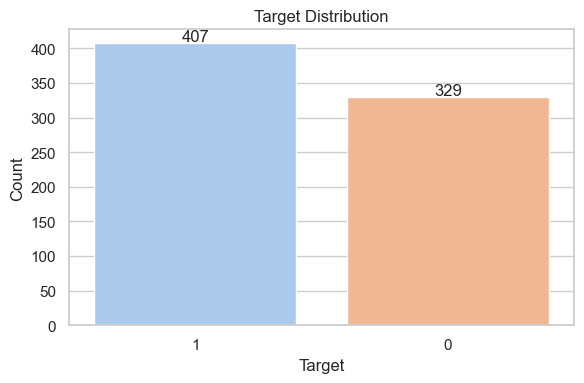

In [11]:
count_series = data_df["Target"].value_counts(dropna=False)
norm_series = data_df["Target"].value_counts(normalize=True, dropna=False)

print("Target counts:")
print(count_series)
print()
print("Target distribution (%):")
print((norm_series * 100).round(2))

plt.figure(figsize=(6, 4))
sns.barplot(x=count_series.index.astype(str), y=count_series.values, palette="pastel")
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
for index, value in enumerate(count_series.values):
    plt.text(index, value + max(count_series.values) * 0.01, str(value), ha="center")
plt.tight_layout()
plt.show()


## 4. Basic Visualization

Plot histograms for numeric features and a feature correlation heatmap.

Numeric columns (10): ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num', 'Target', 'sex_code']
Feature columns used for visualization (7): ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_code']


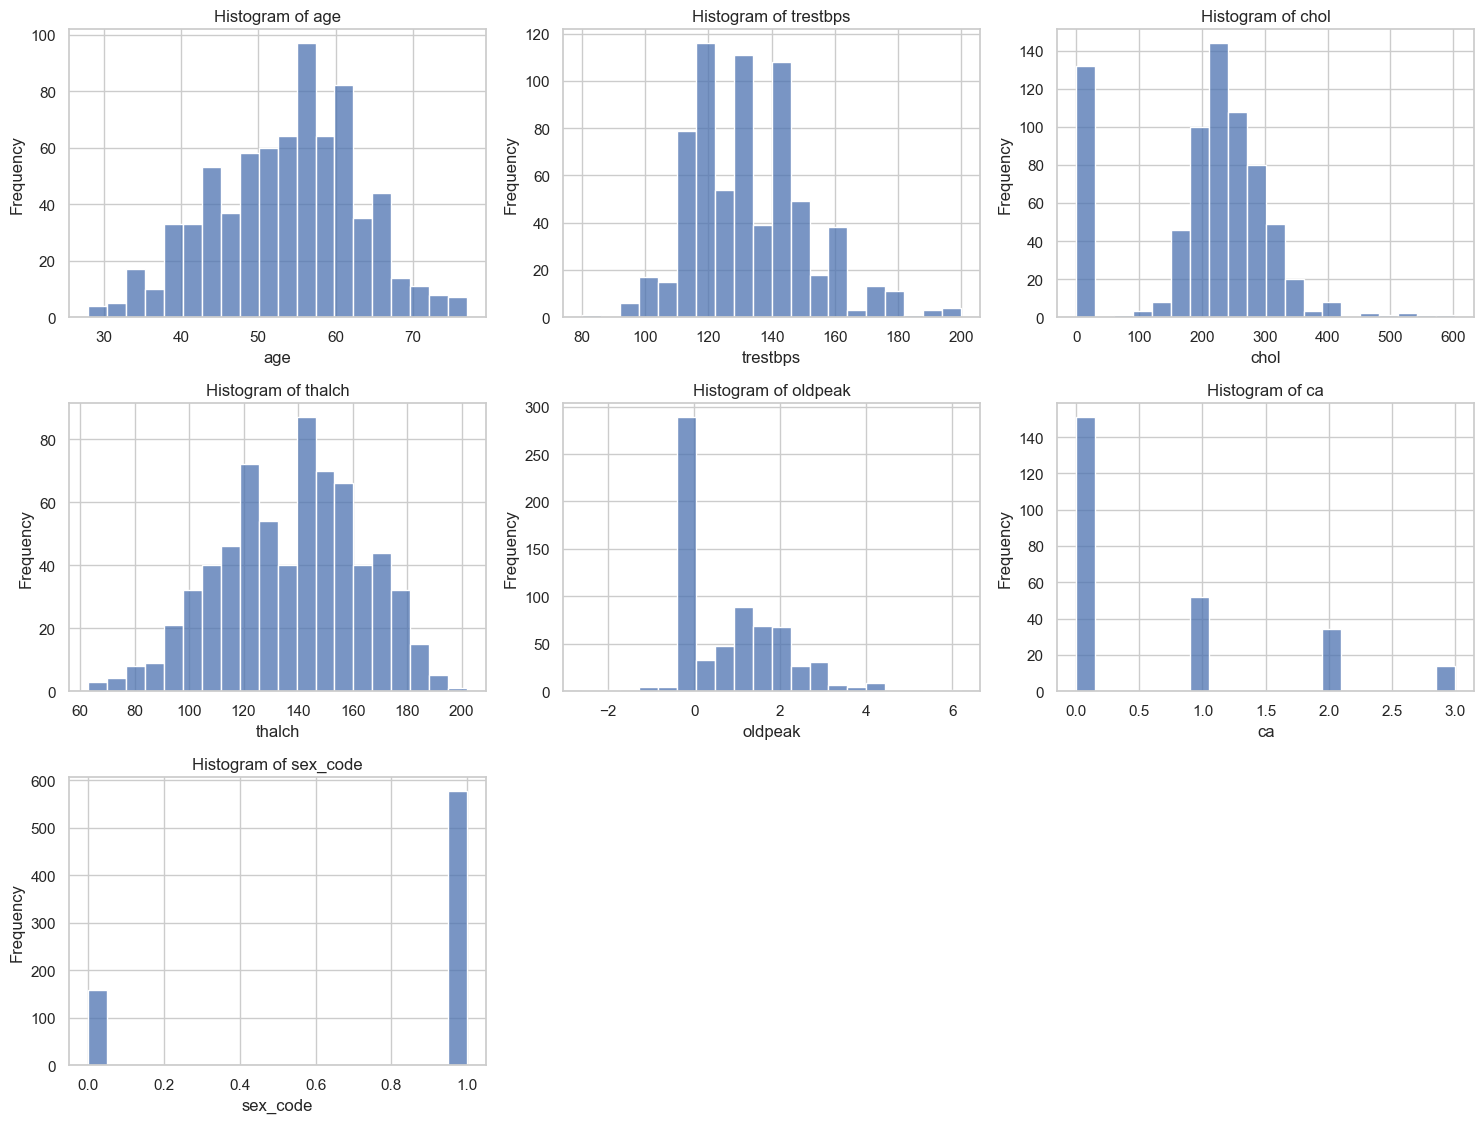

In [12]:
numeric_columns = data_df.select_dtypes(include=["number"]).columns.tolist()
feature_columns = [col for col in numeric_columns if col not in ["id", "Target", "num"]]
print(f"Numeric columns ({len(numeric_columns)}): {numeric_columns}")
print(f"Feature columns used for visualization ({len(feature_columns)}): {feature_columns}")

# Plot histograms for numeric features excluding identifier columns
num_plots = len(feature_columns)
cols = 3
rows = (num_plots + cols - 1) // cols
plt.figure(figsize=(cols * 5, rows * 3.8))
for i, column in enumerate(feature_columns, start=1):
    plt.subplot(rows, cols, i)
    sns.histplot(data_df[column].dropna(), kde=False, bins=20, color="#4c72b0")
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


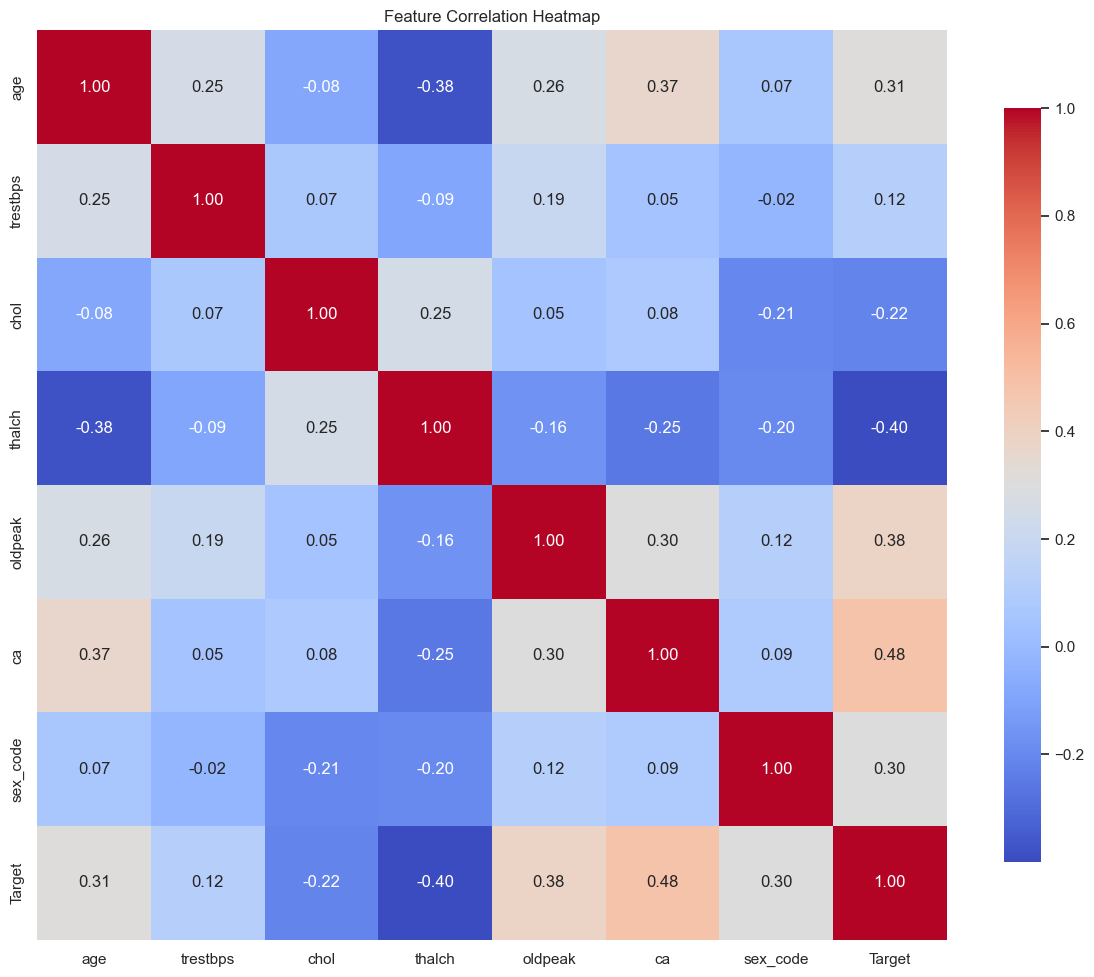

In [13]:
# Correlation heatmap (include sex_code and Target as numeric variables)
heatmap_columns = feature_columns.copy()
if "Target" in data_df.columns:
    heatmap_columns.append("Target")
corr = data_df[heatmap_columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [15]:
# Summarize EDA findings
num_rows, num_cols = data_df.shape
missing = data_df.isnull().sum()
categorical_candidates = [col for col in ["cp", "sex", "dataset", "fbs", "restecg", "exang", "slope", "ca", "thal"] if col in data_df.columns]

print(f"Training dataset shape: {num_rows} rows, {num_cols} columns")
print()
print("Target counts in training set:")
print(data_df["Target"].value_counts(dropna=False))
print()
print("Target ratio in training set (%):")
print((data_df["Target"].value_counts(normalize=True, dropna=False) * 100).round(2))
print()
print(f"Missing values total in training set: {missing.sum()}")
print(missing[missing > 0])
print()
print("Potential categorical columns:")
print(categorical_candidates)
print()
print("Binary classification suitability:")
print("The dataset is suitable for binary classification with Target defined as 0 = no disease and 1 = disease.")
print("The test set is reserved for later evaluation.")


Training dataset shape: 736 rows, 18 columns

Target counts in training set:
Target
1    407
0    329
Name: count, dtype: int64

Target ratio in training set (%):
Target
1    55.3
0    44.7
Name: proportion, dtype: float64

Missing values total in training set: 1398
trestbps     50
chol         27
fbs          68
thalch       47
exang        47
oldpeak      52
slope       241
ca          485
thal        381
dtype: int64

Potential categorical columns:
['cp', 'sex', 'dataset', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Binary classification suitability:
The dataset is suitable for binary classification with Target defined as 0 = no disease and 1 = disease.
The test set is reserved for later evaluation.


### EDA Summary

- EDA was performed on the training set after a train/test split.
- `Target` is a binary variable: 0 = no disease, 1 = disease.
- Missing values have been inspected in the training set. If no values are printed, the training set has no missing values.
- Potential categorical features include `cp`, `sex`, `dataset`, `fbs`, `restecg`, `exang`, `slope`, `ca`, and `thal`.
- The dataset is suitable for binary classification when `Target` is used as the label, and the test set has been reserved for later evaluation.
